In [35]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import collections
import os

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, cohen_kappa_score, make_scorer

# Use imblearn Pipeline so SMOTE runs inside each CV fold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


In [36]:
# Load cleaned diabetes dataset
diabetes_df = pd.read_csv('../data/diabetes/diabetes_cleaned.csv')

print('Dataset loaded successfully')
print('Shape:', diabetes_df.shape)
print('\nColumn names:')
print(diabetes_df.columns.tolist())
print(diabetes_df.head())

Dataset loaded successfully
Shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995        1  
1                 -0.365061 -0.190672        0  
2                  0.604397 -0.105584        1  
3                 -0.920763 -1.041549        0  
4                  5.484909 -0.020496        1  


In [37]:
# Quick sanity check — missing values and data types
print('Missing values:')
print(diabetes_df.isnull().sum())
print('\nData types:')
print(diabetes_df.dtypes)
print('\nTarget distribution (Outcome):')
print(diabetes_df['Outcome'].value_counts())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Target distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


In [38]:
# Separate features (X) and target (y)
X = diabetes_df.drop(columns=['Outcome'])
y = diabetes_df['Outcome']   # 0 = No Diabetes, 1 = Diabetes

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)
print('\nClass distribution:')
print(y.value_counts())
print(f'\nClass imbalance ratio — No Diabetes : Diabetes = '
      f'{y.value_counts()[0]}:{y.value_counts()[1]}')

Features shape: (768, 8)
Target shape:   (768,)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class imbalance ratio — No Diabetes : Diabetes = 500:268


In [39]:
# Train-test split (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print('\nTrain class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

Train : 614 samples
Test  : 154 samples

Train class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [40]:
# Scaling (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only — no leakage

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Scaling done (fit on train only — no leakage).')
print('\nTrain scaled stats (mean ≈ 0, std ≈ 1):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Scaling done (fit on train only — no leakage).

Train scaled stats (mean ≈ 0, std ≈ 1):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
mean       -0.000    0.000         -0.000          0.000   -0.000 -0.000   
std         1.001    1.001          1.001          1.001    1.001  1.001   

      DiabetesPedigreeFunction    Age  
mean                    -0.000 -0.000  
std                      1.001  1.001  


In [41]:
# CV Setup
# SMOTE is NOT applied here — it lives inside each pipeline below
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kappa_scorer = make_scorer(cohen_kappa_score)

def cv_report(pipeline, X, y, label):
    """
    Honest 5-fold CV: SMOTE runs inside each fold via ImbPipeline.
    No synthetic samples ever leak into the validation fold.
    """
    acc   = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
    roc   = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc')
    kappa = cross_val_score(pipeline, X, y, cv=skf, scoring=kappa_scorer)
    print(f'\n[{label}]  5-Fold CV (SMOTE inside fold)')
    print(f'  Accuracy : {acc.mean():.4f}  ±  {acc.std():.4f}')
    print(f'  ROC-AUC  : {roc.mean():.4f}  ±  {roc.std():.4f}')
    print(f'  Kappa    : {kappa.mean():.4f}  ±  {kappa.std():.4f}  ← KEY')
    return {'Accuracy': acc.mean(), 'ROC-AUC': roc.mean(), 'Kappa': kappa.mean()}

cv_results = {}
print('CV setup ready.')

CV setup ready.


In [42]:
OUTPUT_DIR = "../outputs/diabetes/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model 1: Logistic Regression

In [43]:
# Logistic Regression pipeline
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Parameter grid
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

# GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Fit on raw training data
lr_grid.fit(X_train, y_train)

print('Best LR params :', lr_grid.best_params_)
print('Best CV ROC-AUC:', round(lr_grid.best_score_, 4))

lr_best = lr_grid.best_estimator_
cv_results['Logistic Regression'] = cv_report(
    lr_best, X_train, y_train, 'Logistic Regression'
)

Best LR params : {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.8443

[Logistic Regression]  5-Fold CV (SMOTE inside fold)
  Accuracy : 0.7671  ±  0.0072
  ROC-AUC  : 0.8443  ±  0.0157
  Kappa    : 0.5007  ±  0.0125  ← KEY


In [44]:
# Predictions
y_pred_lr = lr_best.predict(X_test)
y_proba_lr = lr_best.predict_proba(X_test)[:, 1]

print('\nTest Set Evaluation (Logistic Regression)')
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_lr), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr,
      target_names=['No Diabetes', 'Diabetes']))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))


Test Set Evaluation (Logistic Regression)
ROC-AUC: 0.8083

Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.80      0.74      0.77       100
    Diabetes       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154


Confusion Matrix:
 [[74 26]
 [19 35]]


# Model 2: Random Forest

In [45]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Use RAW training data
rf_grid.fit(X_train, y_train)

print('Best RF params :', rf_grid.best_params_)
print('Best CV ROC-AUC:', round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_

cv_results['Random Forest'] = cv_report(
    rf_best, X_train, y_train, 'Random Forest'
)

Best RF params : {'classifier__max_depth': 5, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.8397

[Random Forest]  5-Fold CV (SMOTE inside fold)
  Accuracy : 0.7736  ±  0.0156
  ROC-AUC  : 0.8397  ±  0.0231
  Kappa    : 0.5250  ±  0.0265  ← KEY


In [46]:
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print('\nTest Set Evaluation (Random Forest)')
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_rf), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf,
      target_names=['No Diabetes', 'Diabetes']))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))


Test Set Evaluation (Random Forest)
ROC-AUC: 0.8183

Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.87      0.69      0.77       100
    Diabetes       0.59      0.81      0.68        54

    accuracy                           0.73       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.73      0.74       154


Confusion Matrix:
 [[69 31]
 [10 44]]


# Model 3: XGBoost

In [47]:
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 0.5],
    'classifier__reg_lambda': [1, 1.5, 2]
}

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=skf,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

# Use RAW training data
xgb_search.fit(X_train, y_train)

print('Best XGB params :', xgb_search.best_params_)
print('Best CV ROC-AUC :', round(xgb_search.best_score_, 4))

xgb_best = xgb_search.best_estimator_

cv_results['XGBoost'] = cv_report(
    xgb_best, X_train, y_train, 'XGBoost'
)

Best XGB params : {'classifier__subsample': 0.8, 'classifier__reg_lambda': 2, 'classifier__reg_alpha': 0.1, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
Best CV ROC-AUC : 0.8327

[XGBoost]  5-Fold CV (SMOTE inside fold)
  Accuracy : 0.7703  ±  0.0228
  ROC-AUC  : 0.8359  ±  0.0233
  Kappa    : 0.5101  ±  0.0439  ← KEY


In [48]:
y_pred_xgb = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

print('\nTest Set Evaluation (XGBoost)')
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_xgb), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_xgb,
      target_names=['No Diabetes', 'Diabetes']))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_xgb))


Test Set Evaluation (XGBoost)
ROC-AUC: 0.8172

Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.86      0.71      0.78       100
    Diabetes       0.59      0.78      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.74       154


Confusion Matrix:
 [[71 29]
 [12 42]]


In [49]:
# HOLD-OUT TEST SET EVALUATION

print('HOLD-OUT TEST SET RESULTS')

models = {
    'Logistic Regression': lr_best,
    'Random Forest'      : rf_best,
    'XGBoost'            : xgb_best,
}

test_results = {}

for name, model in models.items():
    # IMPORTANT: use RAW X_test, not X_test_scaled
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    roc       = roc_auc_score(y_test, y_prob)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    kappa     = cohen_kappa_score(y_test, y_pred)
    brier     = brier_score_loss(y_test, y_prob)

    test_results[name] = {
        'Accuracy' : acc,
        'ROC-AUC'  : roc,
        'F1'       : f1,
        'Precision': precision,
        'Recall'   : recall,
        'Kappa'    : kappa,
        'Brier'    : brier,
    }

    print(f'\n── {name} ──')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  Kappa     : {kappa:.4f}')
    print(f'  Brier     : {brier:.4f}  (lower = better calibrated)')
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

HOLD-OUT TEST SET RESULTS

── Logistic Regression ──
  Accuracy  : 0.7078
  ROC-AUC   : 0.8083
  F1        : 0.6087
  Precision : 0.5738
  Recall    : 0.6481
  Kappa     : 0.3769
  Brier     : 0.1832  (lower = better calibrated)
              precision    recall  f1-score   support

 No Diabetes       0.80      0.74      0.77       100
    Diabetes       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154


── Random Forest ──
  Accuracy  : 0.7338
  ROC-AUC   : 0.8183
  F1        : 0.6822
  Precision : 0.5867
  Recall    : 0.8148
  Kappa     : 0.4634
  Brier     : 0.1713  (lower = better calibrated)
              precision    recall  f1-score   support

 No Diabetes       0.87      0.69      0.77       100
    Diabetes       0.59      0.81      0.68        54

    accuracy                           0.73       154
   macro avg       0.73      

In [50]:
# OVERFITTING CHECK — CV vs TEST GAP

print('\n' + '='*60)
print('OVERFITTING CHECK — CV vs Hold-out Gap')
print('='*60)
print(f'{"Model":<22} {"CV AUC":>8}  {"Test AUC":>9}  {"Gap":>8}')
print('-'*55)

for name in models:
    cv_auc   = cv_results[name]['ROC-AUC']
    test_auc = test_results[name]['ROC-AUC']
    gap      = cv_auc - test_auc
    flag     = 'Overfit' if gap > 0.05 else 'OK'
    print(f'{name:<22} {cv_auc:>8.4f}  {test_auc:>9.4f}  {gap:>+8.4f}  {flag}')


OVERFITTING CHECK — CV vs Hold-out Gap
Model                    CV AUC   Test AUC       Gap
-------------------------------------------------------
Logistic Regression      0.8443     0.8083   +0.0359  OK
Random Forest            0.8397     0.8183   +0.0214  OK
XGBoost                  0.8359     0.8172   +0.0187  OK


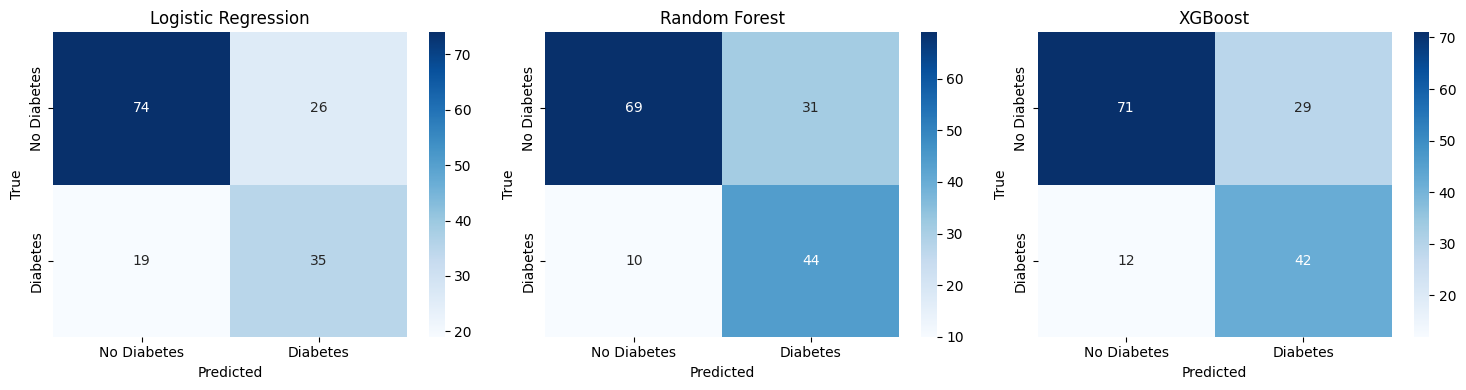

Saved: ../outputs/diabetes/plots/diabetes_confusion_matrices.png


In [51]:
# CONFUSION MATRICES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes']
    )
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/diabetes_confusion_matrices.png', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/diabetes_confusion_matrices.png')

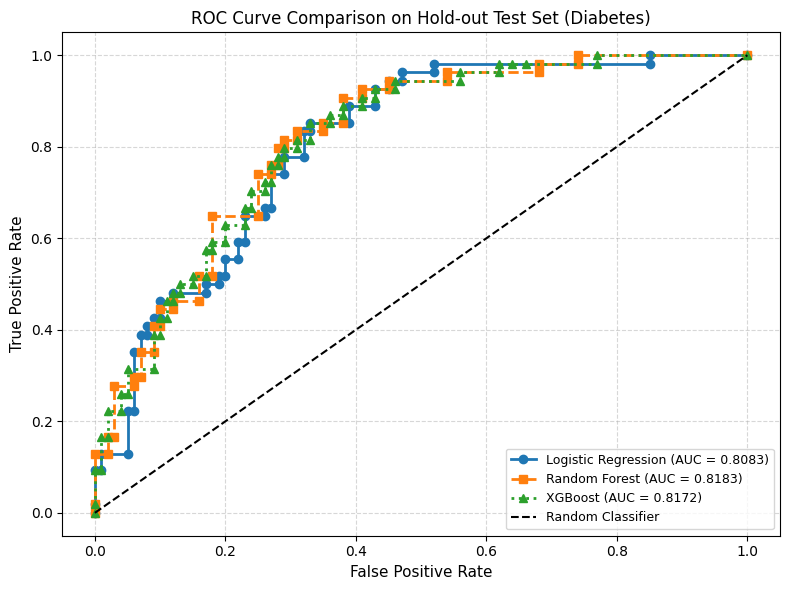

Saved: ../outputs/diabetes/plots/diabetes_roc_curves.png


In [52]:
# ROC CURVES

plt.figure(figsize=(8, 6))

styles = {
    'Logistic Regression': ('-', 'o'),
    'Random Forest': ('--', 's'),
    'XGBoost': (':', '^')
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    line_style, marker_style = styles[name]

    plt.plot(
        fpr, tpr,
        linestyle=line_style,
        marker=marker_style,
        linewidth=2,
        markersize=6,
        label=f'{name} (AUC = {auc:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison on Hold-out Test Set (Diabetes)', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/diabetes_roc_curves.png', dpi=150)
plt.show()

print(f'Saved: {OUTPUT_DIR}/diabetes_roc_curves.png')

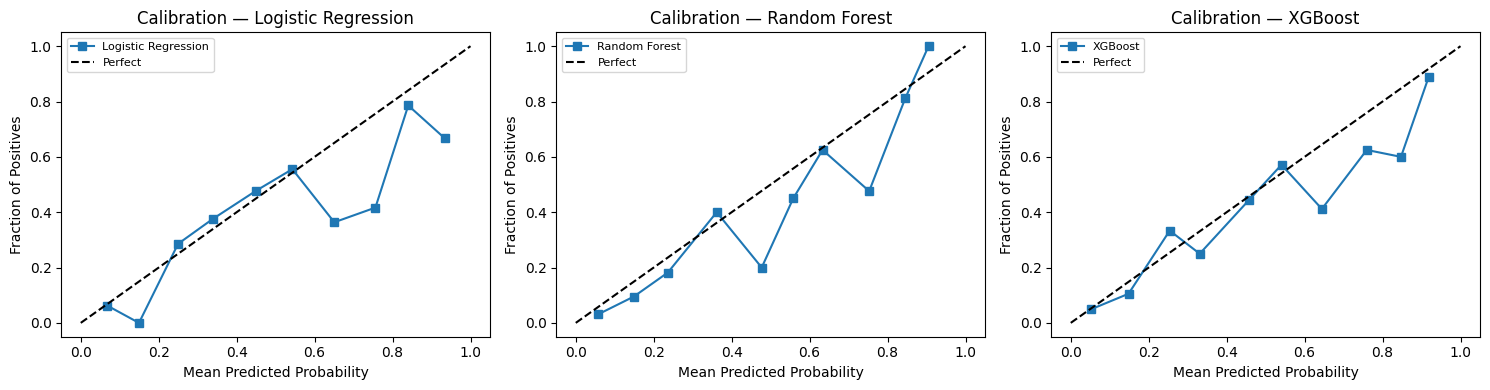

Saved: ../outputs/diabetes/plots/diabetes_calibration_curves.png


In [53]:
# CALIBRATION CURVES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_pred, fraction_pos, 's-', label=name)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.set_title(f'Calibration — {name}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/diabetes_calibration_curves.png', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/diabetes_calibration_curves.png')

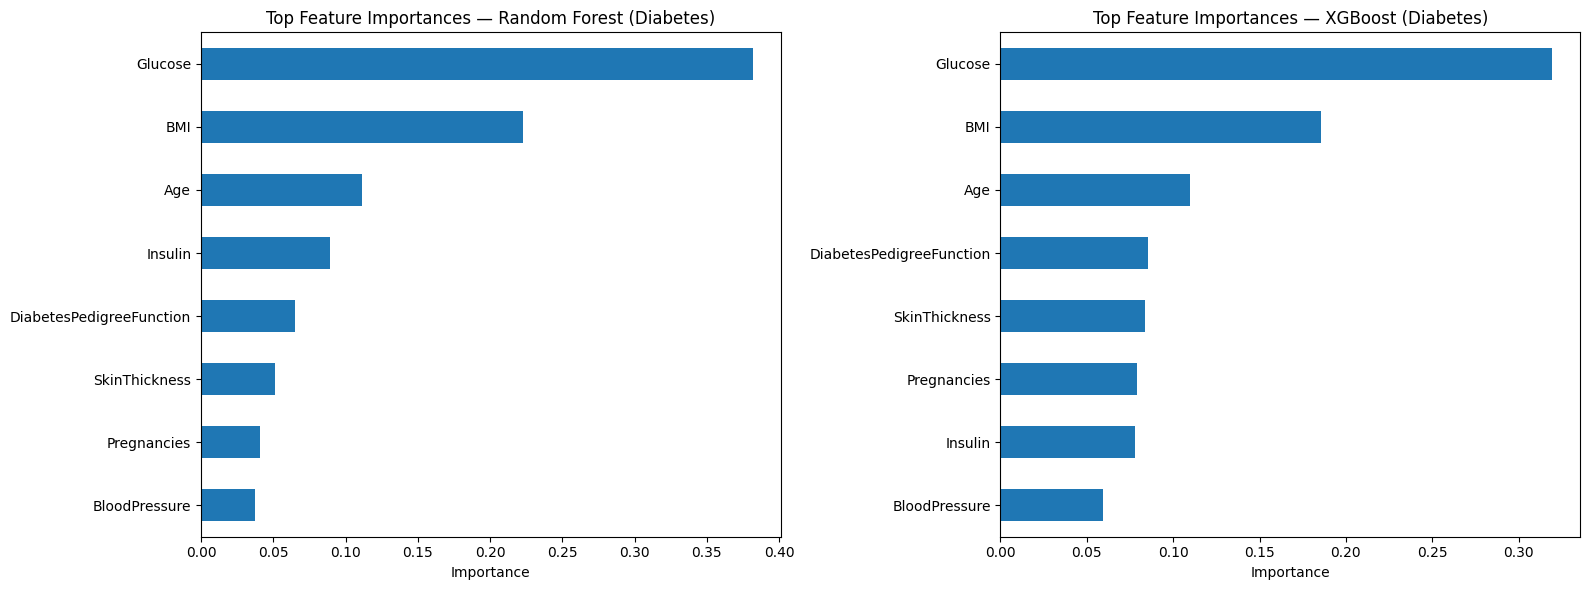

Saved: ../outputs/diabetes/plots/diabetes_feature_importances.png


In [54]:
# FEATURE IMPORTANCE (RF & XGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, [
    ('Random Forest', rf_best),
    ('XGBoost', xgb_best),
]):
    clf = model.named_steps['classifier']
    importances = pd.Series(clf.feature_importances_, index=X.columns)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Top Feature Importances — {name} (Diabetes)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/diabetes_feature_importances.png', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/diabetes_feature_importances.png')

In [56]:
# SAVE MODELS
import os
import joblib

MODEL_DIR = "../models/diabetes"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lr_best,  f"{MODEL_DIR}/diabetes_lr_pipeline.pkl")
joblib.dump(rf_best,  f"{MODEL_DIR}/diabetes_rf_pipeline.pkl")
joblib.dump(xgb_best, f"{MODEL_DIR}/diabetes_xgb_pipeline.pkl")

print(f"All diabetes models saved to {MODEL_DIR}/")

All diabetes models saved to ../models/diabetes/


In [57]:
# FINAL SUMMARY TABLE

summary = pd.DataFrame(test_results).T
summary.index.name = 'Model'

print('\n' + '='*60)
print('FINAL TEST SET SUMMARY — DIABETES')
print('='*60)
print(summary.round(4).to_string())

print('\nBest model by ROC-AUC:', summary['ROC-AUC'].idxmax())
print('Best model by Kappa  :', summary['Kappa'].idxmax())


FINAL TEST SET SUMMARY — DIABETES
                     Accuracy  ROC-AUC      F1  Precision  Recall   Kappa   Brier
Model                                                                            
Logistic Regression    0.7078   0.8083  0.6087     0.5738  0.6481  0.3769  0.1832
Random Forest          0.7338   0.8183  0.6822     0.5867  0.8148  0.4634  0.1713
XGBoost                0.7338   0.8172  0.6720     0.5915  0.7778  0.4548  0.1732

Best model by ROC-AUC: Random Forest
Best model by Kappa  : Random Forest
